## 1- Simple LangGraph LLM Reporter (No Web Search)

In [ ]:
#A simple langgraph which just use the llm model to answer my query(NO WEB SEARCH)

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph

#Foundation model
llm_model = ChatOllama(model="llama3.1:latest")
generate_prompt = SystemMessage(
    """You are a reseracher who create a report based on user query.
    This report should have an Introduction section, Main section and conclusion at least.""")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def research_bot(state:State):
    messages = [generate_prompt, *state["messages"]]
    answer = llm_model.invoke(messages)
    return {"messages": [answer]}

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_edge(START, 'researcher_bot')
builder.add_edge("researcher_bot", END)
graph = builder.compile()

#Draw the graph
draw_graph(graph)

#Final test
query = {"messages": [HumanMessage("What are the latest trends in agentic AI for 2026?")]}
for part in graph.stream(query, stream_mode="messages", version="v2"):
    if part["type"] == "messages":
        message_chunk, metadata = part["data"]
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)


## 2-Adding Web Search Tools to the LangGraph Agent

**DuckDuckGoSearchRun**  
Description (paraphrased):  
A web search tool that queries DuckDuckGo and returns recent, relevant search results (snippets, titles, links) for a given query string.

Use when you need general web search or fresh news, not just encyclopedic facts.

**WikipediaQueryRun**  
Description (from its docstring, lightly paraphrased):  
A wrapper around Wikipedia, useful for answering general questions about people, places, companies, facts, historical events, and other subjects. The input should be a search query.

Use when you want encyclopedia‑style background on a named topic.

**TavilySearchResults**  
Description (from its docs, paraphrased):  
A tool that queries the Tavily Search API and returns a structured JSON response with URLs, content, optional summarized answer, raw content, images, and metadata for a given query.

Use when you want web search with structured, aggregated results (and you have TAVILY_API_KEY

In [ ]:
#Now provide three web search tools for Agent

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import ToolNode, tools_condition



#Variables
MODEL_NAME = "llama3.1:latest"
TAVILY_MAX_RESULTS = 3
WIKI_MAX_CHARS = 500


#Tools are: DuckDuckGo, Tavily and wikipedia
#DuckDuckGo
duckduckgo_search = DuckDuckGoSearchRun()
#Wikipedia
wiki_client = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=WIKI_MAX_CHARS)
wikipedia_search = WikipediaQueryRun(api_wrapper=wiki_client)
#Tavily search(needs an API)-> I got it from tavili site and copy it to my bashrc file
tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)

# Describe the tools clearly(It is for more clear understanding)
duckduckgo_search.name = "current_web_search"
duckduckgo_search.description = (
    "Use this tool to search the live web via DuckDuckGo for up-to-date information, "
    "news, and current events. Prefer this when the user asks for 'latest', 'today', "
    "'2026', or 'current' information."
)

wikipedia_search.name = "wikipedia_summary"
wikipedia_search.description = (
    "Use this tool to get encyclopedia-style background information and definitions "
    "about people, places, concepts, and historical topics from Wikipedia."
)

tavily_search.name = "deep_web_research"
tavily_search.description = (
    "Use this tool to perform deep multi-source web research and return aggregated "
    "results when the user asks for a detailed report, multiple viewpoints, or sources."
)

tools = [duckduckgo_search, wikipedia_search, tavily_search]

#Foundation model binding with above tools
llm_model = ChatOllama(model=MODEL_NAME).bind_tools(tools)

generate_prompt = SystemMessage(
    """You are a reseracher who create a report based on user query.
    This report should have an Introduction, Main  and conclusion sections at least.""")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def research_bot(state: State) -> dict:
    messages = [generate_prompt, *state["messages"]]
    answer = llm_model.invoke(messages)
    # Debug: print tool calls if any
    if answer.tool_calls:
        for tc in answer.tool_calls:
            print(f"🔧 Tool called: {tc['name']} | Input: {tc['args']}")
    return {"messages": [answer]}

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, 'researcher_bot')
builder.add_conditional_edges("researcher_bot", tools_condition)
builder.add_edge("tools", "researcher_bot")
graph = builder.compile()

#Draw the graph
draw_graph(graph)

#Final test
query = {"messages": [HumanMessage("What is the lastest news of Foxnews today?")]}
for part in graph.stream(query, stream_mode="messages", version="v2"):
    if part["type"] == "messages":
        message_chunk, metadata = part["data"]
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)



## 3-Self-Reflecting LangGraph Research Agent  
Here we add reflection agent and seperate it from reseracher agent for better performance.  

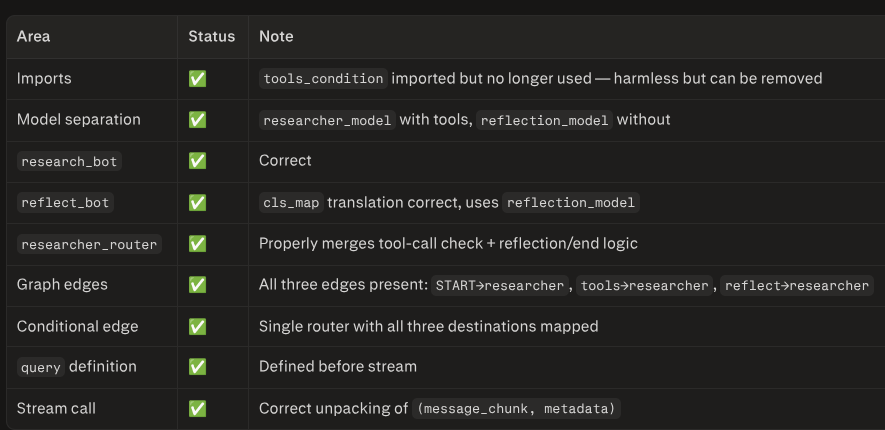

In [ ]:
#Now add Reflection to the agent

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph, pretty_stream
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import ToolNode



#Variables
# Researcher: llama3.1 with tools bound
LLM_MODEL_NAME = "llama3.1:latest"
# Reflect: phi4-mini, no tools
REFLECT_MODEL_NAME = "phi4-mini:latest"
TAVILY_MAX_RESULTS = 3
WIKI_MAX_CHARS = 1500


#Tools are: DuckDuckGo, Tavily and wikipedia
#DuckDuckGo
duckduckgo_search = DuckDuckGoSearchRun()
#Wikipedia
wiki_client = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=WIKI_MAX_CHARS)
wikipedia_search = WikipediaQueryRun(api_wrapper=wiki_client)
#Tavily search(needs an API)-> I got it from tavili site and copy it to my bashrc file
tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)

# Describe the tools clearly(It is for more clear understanding)
duckduckgo_search.name = "current_web_search"
duckduckgo_search.description = (
    "Use this tool to search the live web via DuckDuckGo for up-to-date information, "
    "news, and current events. Prefer this when the user asks for 'latest', 'today', "
    "'2026', or 'current' information."
)

wikipedia_search.name = "wikipedia_summary"
wikipedia_search.description = (
    "Use this tool to get encyclopedia-style background information and definitions "
    "about people, places, concepts, and historical topics from Wikipedia."
)

tavily_search.name = "deep_web_research"
tavily_search.description = (
    "Use this tool to perform deep multi-source web research and return aggregated "
    "results when the user asks for a detailed report, multiple viewpoints, or sources."
)

tools = [tavily_search, wikipedia_search, duckduckgo_search]

#Foundation models for researcher and reflection bots
researcher_model = ChatOllama(model=LLM_MODEL_NAME).bind_tools(tools)
reflection_model = ChatOllama(model=REFLECT_MODEL_NAME)


class State(TypedDict):
    messages: Annotated[list, add_messages]

generate_prompt = SystemMessage(
    """You are a reseracher assistant tasked with writing excellent report."""
    "Generate the best essay possible for the user query."
    """If the user provide critique, respond with a revised version of your previous attempt""")
def research_bot(state: State) -> State:
    messages = [generate_prompt, *state["messages"]]
    answer = researcher_model.invoke(messages)
    # Debug: print tool calls if any
    if answer.tool_calls:
        for tc in answer.tool_calls:
            print(f"🔧 Tool called: {tc['name']} | Input: {tc['args']}")
    return {"messages": [answer]}

reflection_prompt = SystemMessage(
    """You are a teacher grading an essay submission. Generate critique and recommendations for the user's submission."""
    """Provide detailed recommendations, including requests for length, depth, style, etc.""")
def reflect_bot(state: State) -> State:
    #review P157 of book for more detailes
    cls_map = {AIMessage: HumanMessage, HumanMessage: AIMessage, ToolMessage: HumanMessage}
    translated = [reflection_prompt]
    for msg in state["messages"]:
        target_cls = cls_map.get(type(msg), HumanMessage)  # default to HumanMessage
        translated.append(target_cls(content=msg.content))

    answer = reflection_model.invoke(translated)
    return {"messages": [HumanMessage(content=answer.content)]}

#Router
def researcher_router(state: State):
    # First check if the last message has tool calls (tools_condition logic)
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    # Otherwise apply reflection/end logic
    if len(state["messages"]) > 10:
        return END
    return "reflect_bot"
    

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_node("tools", ToolNode(tools))
builder.add_node("reflect_bot", reflect_bot)
builder.add_edge(START, 'researcher_bot')
builder.add_conditional_edges("researcher_bot", researcher_router, {"tools": "tools", "reflect_bot": "reflect_bot", END: END})
builder.add_edge("tools", "researcher_bot") 
builder.add_edge("reflect_bot", "researcher_bot")
graph = builder.compile()

#Draw the graph
draw_graph(graph)


#Final test
query = {"messages": [HumanMessage(" What are the latest trends in agentic AI for 2026?")]}

# Output 
# pretty_stream(graph, query)

# Output as pdf format
from utils import save_text_as_pdf

def get_final_report(state: State) -> str:
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            return msg.content
    return ""

final_text = get_final_report(graph.invoke(query))
save_text_as_pdf(final_text, "initial_report.pdf", title="initial_report")

## 4- Final Project: Tool-Augmented Research Agent with Memory

**Project name:** Project 3 – Tool-Augmented Research Agent with Memory

**What to build:**  
A research assistant that:  
- Takes a user query and searches the web via Tavily.  
- Reads and summarizes specific URLs.  
- Stores findings in short‑term conversation memory (LangGraph state) and long‑term memory (a vector store or external DB).  
- Produces a structured report.  
- Runs a reflection step where a second agent critiques the draft and rewrites weak sections.

**Why it matters:**  
Reflection is a core agent pattern, covered in *Learning LangChain*, Chapter 7 (“Agents II — Reflection”).[web:71][web:42] This project extends your existing Report Writer Agent (Project 2.4 in your interview deck) with persistent memory and self‑critique, aligning with 2026 hiring expectations for agents that reduce hallucinations via debate and reflection.[web:42][web:73]

**Tech stack:**  
- LangGraph (ReAct + dedicated Reflection node)  
- Tavily search  
- LangSmith tracing  
- Redis or Chroma for long‑term memory

**Resume bullet:**  
> Extended a ReAct agent with a Reflection–Critique loop and long‑term memory, demonstrating measurable reduction in hallucination rate on a custom evaluation dataset using LangSmith.[web:42][web:72]

/tmp/ipykernel_384246/4028471057.py:33: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)
/tmp/ipykernel_384246/4028471057.py:59: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  memory_vectorstore = Chroma(


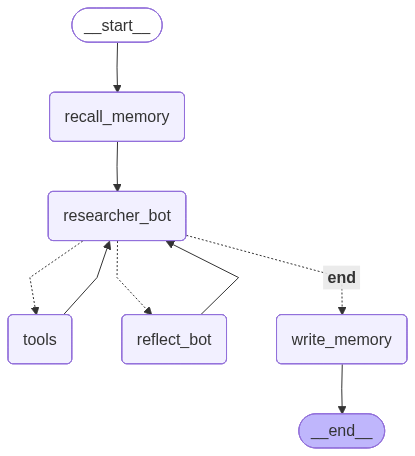

In [2]:
#Now add Reflection to the agent

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph, pretty_stream, save_text_as_pdf
from langchain_community.tools import RequestsGetTool
from langchain_community.utilities.requests import TextRequestsWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings 
from langchain_core.documents import Document


#Variables
# Researcher: llama3.1 with tools bound
LLM_MODEL_NAME = "llama3.1:latest"
# Reflect: phi4-mini, no tools
REFLECT_MODEL_NAME = "phi4-mini:latest"
# Embedding: nomic-embed-text
EMBEDDING_MODEL_NAME = "nomic-embed-text"
TAVILY_MAX_RESULTS = 3
WIKI_MAX_CHARS = 10_000
# Long-term memory vector store
MEMORY_DIR = "./chroma_db"


#Tavily search(needs an API)-> I got it from tavili site and copy it to my bashrc file
tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)
tavily_search.name = "tavily_search"
tavily_search.description = (
    "Searches the web for up-to-date information and returns relevant results. "
    "Use this whenever you need external knowledge or current information."
)

#A URL loader tool
# Create a wrapper around requests
requests_wrapper = TextRequestsWrapper()

read_url = RequestsGetTool(
    requests_wrapper=requests_wrapper,
    allow_dangerous_requests=True)
read_url.name = "read_url"
read_url.description = (
    "Fetches the raw text content of a web page from a given URL. "
    "Use this after you have identified a specific URL that needs deeper reading."
)
tools = [tavily_search, read_url]

#Foundation models for researcher and reflection bots
researcher_model = ChatOllama(model=LLM_MODEL_NAME).bind_tools(tools)
reflection_model = ChatOllama(model=REFLECT_MODEL_NAME)
embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL_NAME) # Embeddings for memory

memory_vectorstore = Chroma(
    collection_name="research_agent_memory",
    embedding_function=embedding_model,
    persist_directory=MEMORY_DIR,
)

class State(TypedDict):
    messages: Annotated[list, add_messages]
    iterations: int  # number of researcher passes

def recall_memory(state: State) -> State:
    user_query = None
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break

    if user_query is None:
        return {"messages": []}

    results = memory_vectorstore.similarity_search(user_query, k=2)
    if not results:
        return {"messages": []}

    context_text = (
        "Here are summarized key findings from previous research reports "
        "that may be relevant. Use this ONLY as background. You still MUST "
        "call `tavily_search` and `read_url` to gather fresh, up-to-date "
        "information for the current query.\n\n"
    )
    for doc in results:
        context_text += f"- {doc.page_content}\n\n"

    memory_msg = SystemMessage(content=context_text)
    return {"messages": [memory_msg]}

generate_prompt = SystemMessage("""
You are an expert research assistant tasked with producing a high-quality, structured research report.

You have access to these tools:
- `tavily_search`: search the web for up-to-date information.
- `read_url`: fetch and read specific URLs in depth.

CRITICAL RULES:
- When you need external information, you MUST call these tools using the tool-calling API, NOT by writing JSON or describing function calls in the answer.
- Never include raw JSON with "name" and "parameters" in the final report. Use actual tool calls instead.
- Always call `tavily_search` at least once for any non-trivial factual question, even if you have prior memory.

When given a query:

1. Whenever external knowledge is needed, first call the Tavily search tool to gather relevant links and snippets from the web.
2. If you identify specific URLs that look especially important or are requested by the user, call the `read_url` tool to fetch the full page content for deeper reading.
3. Use the information from Tavily and `read_url` to write a well-structured report with the following sections:
   - **Overview**: A concise summary of the topic (multiple sentences).
   - **Key Findings**: 6-8 bullet points of the most important facts or trends, each supported by a source.
   - **Analysis**: multiple paragraphs of in-depth analysis, connecting the findings and drawing conclusions.
   - **Conclusion**: A paragraph summarizing the significance and outlook.

If you receive a critique of a previous draft:
- Carefully address each point raised.
- Revise the report structure, depth, and style accordingly.
- Do NOT simply restate the original — produce a meaningfully improved version.
"You may also receive prior research summaries as system messages. "
"Use them as helpful background, but always verify important facts with fresh tool calls."
Always cite your sources inline (e.g., "According to Deloitte Insights...") and base factual claims on information obtained from your tools or prior context.
""")

def research_bot(state: State) -> State:
    messages = [generate_prompt, *state["messages"]]
    answer = researcher_model.invoke(messages)
    if answer.tool_calls:
        for tc in answer.tool_calls:
            print(f"🔧 Tool called: {tc['name']} | Input: {tc['args']}")
    return {
        "messages": [answer],
        "iterations": state.get("iterations", 0) + 1,
    }

reflection_prompt = SystemMessage("""
You are a senior research editor reviewing a draft report. Your job is to provide precise, constructive critique — not to rewrite the report yourself.

Evaluate the draft on the following criteria and give specific, actionable feedback for each:

1. **Accuracy**: Are the facts correct and well-sourced? Flag any unsupported or vague claims.
2. **Depth**: Does the report go beyond surface-level observations? Identify sections that need more detail or evidence.
3. **Structure**: Is the report clearly organized with an Overview, Key Findings, Analysis, and Conclusion?
4. **Clarity**: Are there any confusing sentences, jargon, or unclear transitions? Point them out.
5. **Completeness**: Are there important aspects of the topic that are missing or underexplored?
6. **Style**: Is the tone professional and analytical? Flag anything that sounds too generic or conversational.
"If the draft ignores relevant prior research (as given in system messages), call that out."                                    
Format your critique as a numbered list. Be specific — reference actual sentences or sections from the draft.
Do NOT rewrite the report. Only provide critique and recommendations.
""")
def reflect_bot(state: State) -> State:
    # Find the last AIMessage as the current draft
    last_ai: BaseMessage | None = None
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            last_ai = msg
            break

    if last_ai is None:
        # No draft yet; nothing to reflect on
        return {"messages": []}

    messages = [
        reflection_prompt,
        HumanMessage(content="Here is the current draft report:\n\n" + last_ai.content),
    ]
    answer = reflection_model.invoke(messages)

    # Store critique as a HumanMessage so the researcher treats it as user feedback
    return {"messages": [HumanMessage(content=answer.content)]}

#Router
MAX_RESEARCH_PASSES = 2  # or 1 if you want exactly one reflection round

def researcher_router(state: State):
    last_message = state["messages"][-1]

    # If the model just requested tools, go to ToolNode
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    # Stop after N researcher passes
    if state.get("iterations", 0) >= MAX_RESEARCH_PASSES:
        return END

    # Otherwise, send to reflection
    return "reflect_bot"

def write_memory(state: State) -> State:
    # Find the latest AIMessage = final report
    last_ai = None
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            last_ai = msg
            break

    if last_ai is None:
        return {}

    content_raw = last_ai.content.strip()
    content = content_raw.lower()

    # Heuristics: skip if it looks like a tool plan / JSON-focused output
    bad_patterns = [
        "here is a json response",
        "here is the json for a function call",
        "here is the json for function calls",
        "here is a json for a function call",
        '{"name": "tavily_search"',
        '{"name": "read_url"',
        "name\": \"tavily_search\"",
        "name\": \"read_url\"",
    ]
    if any(p in content for p in bad_patterns):
        return {}

    # Require that it looks like a report with sections
    if "overview" not in content or "key findings" not in content:
        return {}

    # Now we trust 'last_ai' is a real report
    full_report = content_raw

    # Capture the original user query for metadata
    user_query = None
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break

    doc = Document(
        page_content=full_report,
        metadata={
            "source": "research_agent",
            "query": user_query or "",
            "type": "full_report",
        },
    )
    memory_vectorstore.add_documents([doc])
    return {}

#Now build the graph
builder = StateGraph(State)

# Existing nodes
builder.add_node("researcher_bot", research_bot)
builder.add_node("tools", ToolNode(tools))
builder.add_node("reflect_bot", reflect_bot)
# New memory nodes
builder.add_node("recall_memory", recall_memory)
builder.add_node("write_memory", write_memory)
# Start: recall long-term memory first
builder.add_edge(START, "recall_memory")
builder.add_edge("recall_memory", "researcher_bot")
# Researcher routing (as before, maybe tweaked for your reflection logic)
builder.add_conditional_edges(
    "researcher_bot",
    researcher_router,
    {
        "tools": "tools",
        "reflect_bot": "reflect_bot",
        END: "write_memory",  # when done, go to write_memory instead of END directly
    },
)

builder.add_edge("tools", "researcher_bot")
builder.add_edge("reflect_bot", "researcher_bot")
# After writing memory, end the graph
builder.add_edge("write_memory", END)
graph = builder.compile()

#Draw the graph
draw_graph(graph)


#Final test
query = {
    "messages": [HumanMessage("What are the latest technology trends in 2026?")],
    "iterations": 0,
}

# Output 
# pretty_stream(graph, query)

# Output as pdf format
def get_final_report(state: State) -> str:
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage):
            return msg.content
    return ""

# final_text = get_final_report(graph.invoke(query))
# save_text_as_pdf(final_text, "final_report.pdf", title="final_report")

In [5]:
query2 = {
    "messages": [HumanMessage("What are the main risks of adopting these LLM trends in highly regulated industries like Military?")],
    "iterations": 0,
}

state2 = graph.invoke(query2)
final_text2 = get_final_report(state2)
print(final_text2)

🔧 Tool called: tavily_search | Input: {'query': 'LLM adoption risks in highly regulated industries'}
Based on the search results, the main risks of adopting LLM trends in highly regulated industries like Military are:

1. **Accuracy**: The use of LLMs may inadvertently expose sensitive data, leading to severe compliance breaches.
2. **Data Security**: There is a risk of data leaks and unauthorized access due to the integration of LLMs with business processes.
3. **Regulatory Compliance**: The rapid development of LLM technology has outpaced the updating of relevant laws, regulations, and industry guidelines, creating substantial compliance uncertainty for participants.
4. **Cybersecurity**: Denial-of-service (DoS) attacks pose a risk to system performance, slowing or halting legitimate BI queries.

To mitigate these risks, it is essential to:

1. Develop clear ethical guidelines and conduct regular audits to ensure LLM usage aligns with regulations.
2. Leverage LLMs to stay ahead of re

In [6]:
test_query = "What are the main risks of adopting these LLM trends in highly regulated industries like military?"

results = memory_vectorstore.similarity_search(test_query, k=1)

print(f"Found {len(results)} docs in memory:\n")
for i, doc in enumerate(results, start=1):
    print(f"--- Doc {i} ---")
    print("METADATA:", doc.metadata)
    print("CONTENT:")
    print(doc.page_content)
    print()


Found 1 docs in memory:

--- Doc 1 ---
METADATA: {'type': 'full_report', 'source': 'research_agent', 'query': 'What are the main risks of adopting these LLM trends in highly regulated industries like finance?'}
CONTENT:
**Overview**

Large Language Models (LLMs) are being adopted by financial institutions to enhance various processes such as analyzing financial reports, automating customer service, detecting fraud, and conducting market sentiment analysis. However, the adoption of LLMs in highly regulated industries like finance is still in its early stages due to factors such as data privacy concerns, regulatory compliance, and the need for specialized fine-tuning to ensure accuracy in finance-specific applications.

**Key Findings**

*   Concentration risk: The current scale of LLMs is dominated by a handful of providers, which may lead to concentration risk and opportunity for data asymmetry.
*   Data, model, and governance risks: LLMs pose significant limiting factors for financial